# Module 31 — Agent Loops & Harnesses

**Part VIII · Agents & Evaluation · 30–35 min**

---

In Module 30 we taught a model to call a tool. One call. One result. Done. That was the easy part.

Real agents don't fire one tool call. They fire a tool call, look at the result, decide it's not enough, fire another, get confused, retry, sometimes loop forever, sometimes give up two steps before the answer. The thing that makes that *work* — or fail — is not the model. It's the **harness**: the while loop, the state object, the budget, the prompt that tells the model what tools exist, the parser that turns model output into an action.

This module's thesis is blunt:

> **Most "agent failures" are harness failures.**

Bad prompts. No budget cap. State that gets silently truncated. A regex that misparses a tool call. Hallucinated tool names that the harness happily forwards instead of catching. None of that is the model's fault. All of it is yours.

We're going to build a working agent in about 100 lines, run it on a real-ish multi-step task, and then deliberately break it five different ways so you can see each failure mode in its natural habitat. We'll use a *deterministic mock LLM* — no API keys, no network — because the point is the harness, not the model.


## 0 · Setup

No external dependencies. Just stdlib + matplotlib + networkx for the state-machine diagram.


In [1]:
import re
import json
import math
import time
import random
from dataclasses import dataclass, field
from typing import Callable, Any
import matplotlib.pyplot as plt
import networkx as nx

random.seed(0)
print("ready")

ready


## 1 · What is an agent, formally and honestly

If you want to sound impressive at a conference, an agent is a **POMDP**:

$$
(\,S,\;A,\;T,\;R,\;O,\;\Omega\,)
$$

where $S$ is the (hidden) world state, $A$ is the action space, $T(s'\mid s,a)$ is the transition function, $R(s,a)$ is reward, $O$ is the observation space, and $\Omega(o\mid s')$ is the observation function. The agent picks a policy $\pi(a\mid h)$ over action histories $h$ to maximize expected return.

If you want to be honest, an agent is this:

```python
state = initial_state()
while not done(state) and budget_left(state):
    obs   = observe(state)
    think = llm(prompt(state, obs))
    act   = parse_action(think)
    state = apply(state, act)
return finalize(state)
```

That's it. A while loop around an LLM. Everything else — ReAct, plan-and-execute, tree search, swarms — is a variation on what `prompt`, `parse_action`, and `apply` look like. The POMDP framing is useful when you're proving things; the while-loop framing is useful when you're debugging at 2 AM.

Let's make it concrete. The pieces of state in a typical chat-style agent:

| Component | What it holds | Why it matters |
|---|---|---|
| `system_prompt` | Tool list, role, rules | If the model doesn't know a tool exists, it can't call it. |
| `history` | All messages so far | Context window. Truncate carelessly and you lose tool results. |
| `tool_results` | Outputs of recent tool calls | Where most "amnesia" bugs live. |
| `budget` | Steps / tokens / dollars left | The only thing standing between you and an infinite loop. |
| `scratchpad` | Model's reasoning trace | Optional but enormously helpful for debugging. |

Three of those five rows ("Why it matters" column) are about failure modes, not capabilities. Hold that thought.


## 2 · The agent loop, drawn

Before we implement anything, let's draw the state machine. Most agent bugs are easier to see as a graph than as code.


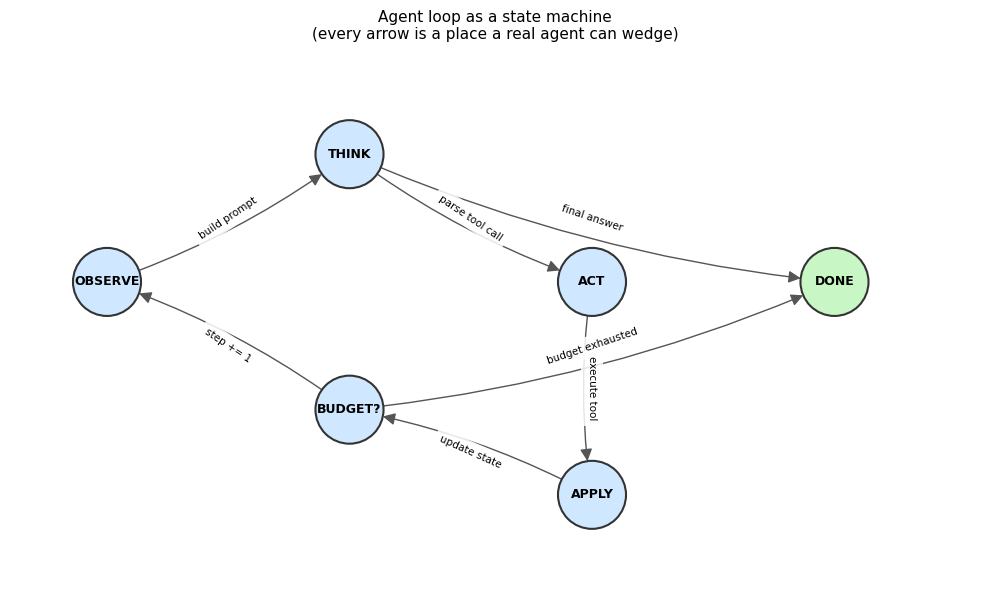

In [2]:
fig, ax = plt.subplots(figsize=(10, 6))
G = nx.DiGraph()

nodes = {
    "OBSERVE":  (0, 1),
    "THINK":    (1.5, 1.6),
    "ACT":      (3, 1),
    "APPLY":    (3, 0),
    "DONE":     (4.5, 1),
    "BUDGET?":  (1.5, 0.4),
}
for n, (x, y) in nodes.items():
    G.add_node(n, pos=(x, y))

edges = [
    ("OBSERVE", "THINK", "build prompt"),
    ("THINK",   "ACT",   "parse tool call"),
    ("ACT",     "APPLY", "execute tool"),
    ("APPLY",   "BUDGET?", "update state"),
    ("BUDGET?", "OBSERVE", "step += 1"),
    ("THINK",   "DONE",  "final answer"),
    ("BUDGET?", "DONE",  "budget exhausted"),
]
for a, b, _ in edges:
    G.add_edge(a, b)

pos = nx.get_node_attributes(G, "pos")
colors = ["#cfe8ff" if n != "DONE" else "#c8f7c5" for n in G.nodes]
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=2400, edgecolors="#333", linewidths=1.5)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=9, font_weight="bold")
nx.draw_networkx_edges(G, pos, ax=ax, arrowsize=18, edge_color="#555",
                       connectionstyle="arc3,rad=0.08", node_size=2400)
edge_labels = {(a, b): l for a, b, l in edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7.5, ax=ax,
                             label_pos=0.5, bbox=dict(facecolor="white", edgecolor="none", alpha=0.85))

ax.set_title("Agent loop as a state machine\n(every arrow is a place a real agent can wedge)", fontsize=11)
ax.set_xlim(-0.6, 5.4)
ax.set_ylim(-0.4, 2.1)
ax.axis("off")
plt.tight_layout()
plt.show()

Notice the two arrows into `DONE`. One is the happy path (the model produced a final answer). The other is the budget bailout. **A harness without a budget bailout is not an agent — it's a hang waiting to happen.**


## 3 · ReAct: the pattern that won

[ReAct (Yao et al., 2022)](https://arxiv.org/abs/2210.03629) is the dominant pattern in production agent harnesses, and it's almost embarrassingly simple. You ask the model to alternate two kinds of output:

```
Thought: I need to find the oldest note about Python.
Action: search("Python")
Observation: [note_3 from 2024-11-02, note_7 from 2025-03-14, ...]
Thought: note_3 is older. I need its age in days.
Action: calculator("(2026-04-11) - (2024-11-02) in days")
Observation: 525
Thought: Doubled = 1050.
Action: final_answer(1050)
```

The "Thought" lines aren't load-bearing for the LLM — modern models would do fine without them — but they're load-bearing for *you*, because they make the trace inspectable. When something goes wrong (and it will), you can read the thought and instantly tell whether the model misunderstood the task, picked the wrong tool, or got the right tool but bad arguments.

That's the entire pattern. `Thought → Action → Observation → Thought → ...`. Now let's build a harness that runs it.


## 4 · Three tools

Our agent will have three tools. We're keeping them small so you can hold the whole system in your head.

1. **`calculator(expr)`** — evaluates a math expression. Real calculators in production agents wrap `sympy` or shell out to a sandbox; ours uses a restricted `eval`.
2. **`note_search(query)`** — full-text-ish search over a tiny in-memory note corpus.
3. **`note_get(note_id)`** — fetches a specific note's content + metadata.


In [3]:
# A tiny corpus of notes. Each has an id, a date, and content.
NOTES = [
    {"id": "n1",  "date": "2024-08-12", "text": "Started learning Rust. Borrow checker is brutal but fair."},
    {"id": "n2",  "date": "2024-11-02", "text": "Python async is fine once you stop fighting the event loop."},
    {"id": "n3",  "date": "2025-01-19", "text": "Set up a homelab. Proxmox + 3 nodes."},
    {"id": "n4",  "date": "2025-03-14", "text": "Wrote a Python script to back up the homelab nightly."},
    {"id": "n5",  "date": "2025-07-30", "text": "Trying out Zig. Comptime is wild."},
    {"id": "n6",  "date": "2025-10-04", "text": "Refactored the Python backup into proper modules."},
    {"id": "n7",  "date": "2026-02-21", "text": "Migrating notes from plaintext to SQLite."},
]

def calculator(expr: str) -> str:
    """Evaluate a math expression. Restricted: only digits, operators, parens, dot."""
    if not re.fullmatch(r"[0-9+\-*/().\s]+", expr):
        return f"ERROR: unsafe expression: {expr!r}"
    try:
        return str(eval(expr, {"__builtins__": {}}, {}))
    except Exception as e:
        return f"ERROR: {e}"

def note_search(query: str) -> str:
    q = query.lower()
    hits = [n for n in NOTES if q in n["text"].lower()]
    if not hits:
        return "no matches"
    return json.dumps([{"id": n["id"], "date": n["date"]} for n in hits])

def note_get(note_id: str) -> str:
    for n in NOTES:
        if n["id"] == note_id:
            return json.dumps(n)
    return f"ERROR: no note {note_id!r}"

# quick smoke test
print(calculator("2 + 3 * 4"))
print(note_search("Python"))
print(note_get("n2"))

14
[{"id": "n2", "date": "2024-11-02"}, {"id": "n4", "date": "2025-03-14"}, {"id": "n6", "date": "2025-10-04"}]
{"id": "n2", "date": "2024-11-02", "text": "Python async is fine once you stop fighting the event loop."}


Three things to notice already:

- The calculator **returns errors as strings** instead of raising. The model needs to *see* the error so it can recover. If you raise a Python exception, the harness crashes and the model never gets a chance to fix its mistake.
- `note_search` returns **JSON, not prose**. Structure in, structure out. Easier to parse, easier to extend.
- `note_get` returns an error string for missing IDs. Same reason: the model needs to know it asked for something that doesn't exist.

These look like trivial design choices. They are not. Tool error semantics is one of the biggest sources of silent agent failures in production. We'll see one such failure later in the module.


## 5 · The mock LLM

We're going to use a deterministic "model" that follows simple rules. It's not pretending to be smart — it's pretending to be *reliable enough that the harness is what we're testing*. If we used a real LLM, you'd never know whether a bug was in our harness or in Claude/GPT's mood that day.

The mock looks at the task description, the history of observations, and emits a `Thought:` + `Action:` block in the ReAct format. We hard-code the policy for our one demo task.


In [4]:
class MockLLM:
    """Deterministic ReAct policy for the demo task.

    State machine inside the model's 'head':
      0: haven't searched yet     -> search('Python')
      1: have search results      -> pick oldest, calculator on its age
      2: have age in days         -> double it, return final answer
    """
    def __init__(self):
        self.calls = 0

    def __call__(self, prompt: str, history: list) -> str:
        self.calls += 1
        # Look at observations in the history to decide what stage we're at.
        obs = [m for m in history if m["role"] == "tool"]

        if len(obs) == 0:
            return ('Thought: I need to find notes that mention "Python", '
                    'then identify the oldest one.\n'
                    'Action: note_search("Python")')

        if len(obs) == 1:
            # Parse the search results, find oldest date.
            try:
                hits = json.loads(obs[0]["content"])
            except Exception:
                return 'Thought: search failed.\nAction: final_answer("could not search")'
            oldest = min(hits, key=lambda h: h["date"])
            # Compute days from oldest date to today (2026-04-11) using a simple formula.
            # We let the calculator do it via day-of-year arithmetic.
            y, m, d = map(int, oldest["date"].split("-"))
            days_oldest = (y - 2000) * 365 + (m - 1) * 30 + d
            days_today = (2026 - 2000) * 365 + (4 - 1) * 30 + 11
            expr = f"{days_today} - {days_oldest}"
            return (f'Thought: oldest hit is {oldest["id"]} from {oldest["date"]}. '
                    f'Computing age in days.\n'
                    f'Action: calculator("{expr}")')

        if len(obs) == 2:
            try:
                age = int(obs[1]["content"])
            except Exception:
                return 'Thought: calc failed.\nAction: final_answer("calc error")'
            return (f'Thought: age is {age} days. Doubling.\n'
                    f'Action: calculator("{age} * 2")')

        if len(obs) == 3:
            doubled = obs[2]["content"]
            return (f'Thought: doubled = {doubled}. Done.\n'
                    f'Action: final_answer({doubled})')

        # Fallback. Should never happen on the happy path.
        return 'Thought: out of ideas.\nAction: final_answer("unknown")'


Yes, this is fake. That's the *whole point*. When we deliberately break the harness in section 8, you'll see that the failures happen even though the "model" is perfect. That's the lesson: **the model isn't your bottleneck.**


## 6 · The harness, in ~100 lines

Here it is. Read it carefully — this is the entire object of study for the rest of the module.


In [5]:
@dataclass
class AgentState:
    task: str
    history: list = field(default_factory=list)   # [{role, content}]
    step: int = 0
    max_steps: int = 8
    done: bool = False
    final_answer: Any = None
    trace: list = field(default_factory=list)     # for inspection

ACTION_RE = re.compile(r'Action:\s*(\w+)\((.*)\)\s*$', re.MULTILINE | re.DOTALL)

class AgentHarness:
    def __init__(self, llm, tools: dict, max_steps: int = 8, verbose: bool = True):
        self.llm = llm
        self.tools = tools
        self.max_steps = max_steps
        self.verbose = verbose

    def system_prompt(self, task: str) -> str:
        tool_lines = "\n".join(f"- {name}(...)" for name in self.tools)
        return (f"You are an agent. Task: {task}\n"
                f"Tools available:\n{tool_lines}\n"
                f"Use ReAct format: 'Thought: ...\\nAction: tool_name(args)'.\n"
                f"When done, call final_answer(result).")

    def parse_action(self, text: str):
        m = ACTION_RE.search(text)
        if not m:
            return None, None
        name, raw_args = m.group(1), m.group(2).strip()
        # Strip surrounding quotes if present.
        if (raw_args.startswith('"') and raw_args.endswith('"')) or \
           (raw_args.startswith("'") and raw_args.endswith("'")):
            raw_args = raw_args[1:-1]
        return name, raw_args

    def run(self, task: str) -> AgentState:
        state = AgentState(task=task, max_steps=self.max_steps)
        state.history.append({"role": "system", "content": self.system_prompt(task)})

        while not state.done and state.step < state.max_steps:
            state.step += 1
            # 1. THINK: ask the model.
            think = self.llm(self.system_prompt(task), state.history)
            state.history.append({"role": "assistant", "content": think})
            state.trace.append({"step": state.step, "kind": "think", "text": think})
            if self.verbose:
                print(f"\n[step {state.step}] {think}")

            # 2. PARSE.
            tool, args = self.parse_action(think)
            if tool is None:
                state.trace.append({"step": state.step, "kind": "error", "text": "no action"})
                if self.verbose: print("  -> harness: no action found, stopping")
                break

            # 3. TERMINATE?
            if tool == "final_answer":
                state.final_answer = args
                state.done = True
                state.trace.append({"step": state.step, "kind": "final", "text": args})
                if self.verbose: print(f"  -> FINAL: {args}")
                break

            # 4. ACT: dispatch to tool.
            if tool not in self.tools:
                obs = f"ERROR: unknown tool {tool!r}"
            else:
                try:
                    obs = self.tools[tool](args)
                except Exception as e:
                    obs = f"ERROR: tool raised: {e}"

            state.history.append({"role": "tool", "content": obs})
            state.trace.append({"step": state.step, "kind": "obs", "tool": tool, "text": obs})
            if self.verbose: print(f"  -> {tool}({args!r}) = {obs}")

        if not state.done:
            state.trace.append({"step": state.step, "kind": "budget_exhausted"})
            if self.verbose: print(f"\n[budget exhausted after {state.step} steps]")
        return state

TOOLS = {
    "calculator":  calculator,
    "note_search": note_search,
    "note_get":    note_get,
}
print("harness ready")

harness ready


Take a minute and stare at this. Things to notice:

- **Single while loop.** The loop body has exactly four phases: think, parse, maybe-terminate, act. There is no recursion, no callbacks, no `asyncio`. Get this right before you reach for anything fancier.
- **Budget is a hard cap on the loop.** It's checked *in the loop condition*, not somewhere inside. This is the only structural defense against infinite loops. If you put it inside an `if` branch, you've already lost.
- **`final_answer` is a fake tool.** The model "calls" it like a tool, but the harness intercepts and treats it as the termination signal. This is the standard trick. Some frameworks call it `submit`, `respond`, or `done`. Same idea.
- **Unknown tools become observations, not crashes.** If the model hallucinates a tool name, the harness returns an error string and lets the model recover. This is *crucial*, and we'll demo what happens when you forget it.
- **Every iteration appends to a trace.** This is the difference between an agent you can debug and one you can't.


## 7 · Running the happy path

The task: *"Find the oldest note mentioning Python, compute its age in days as of today (2026-04-11), then double it."*

If the harness works, we should see exactly four model calls:
1. search for "Python"
2. compute the age in days
3. double it
4. emit final answer


In [6]:
llm = MockLLM()
agent = AgentHarness(llm=llm, tools=TOOLS, max_steps=8, verbose=True)
result = agent.run("Find the oldest note mentioning Python, compute its age in days as of 2026-04-11, then double it.")
print(f"\n=== final answer: {result.final_answer} ===")
print(f"=== llm calls: {llm.calls}, harness steps: {result.step} ===")


[step 1] Thought: I need to find notes that mention "Python", then identify the oldest one.
Action: note_search("Python")
  -> note_search('Python') = [{"id": "n2", "date": "2024-11-02"}, {"id": "n4", "date": "2025-03-14"}, {"id": "n6", "date": "2025-10-04"}]

[step 2] Thought: oldest hit is n2 from 2024-11-02. Computing age in days.
Action: calculator("9591 - 9062")
  -> calculator('9591 - 9062') = 529

[step 3] Thought: age is 529 days. Doubling.
Action: calculator("529 * 2")
  -> calculator('529 * 2') = 1058

[step 4] Thought: doubled = 1058. Done.
Action: final_answer(1058)
  -> FINAL: 1058

=== final answer: 1058 ===
=== llm calls: 4, harness steps: 4 ===


Let's sanity-check the math. The oldest Python note is `n2` from 2024-11-02. Using our toy day arithmetic:

- today (2026-04-11) → 26·365 + 3·30 + 11 = 9490 + 90 + 11 = **9591**
- n2 (2024-11-02) → 24·365 + 10·30 + 2 = 8760 + 300 + 2 = **9062**
- diff = 529, doubled = **1058**

(Yes, this is fake calendar math — months are 30 days, no leap years. The real point is the agent did three correct tool calls in the right order. If you want a real ephemeris, give it a real date library as a tool. The harness wouldn't change one byte.)


## 8 · The trace, visualized

Let's draw the loop iterations as a swimlane so you can see what touched what.


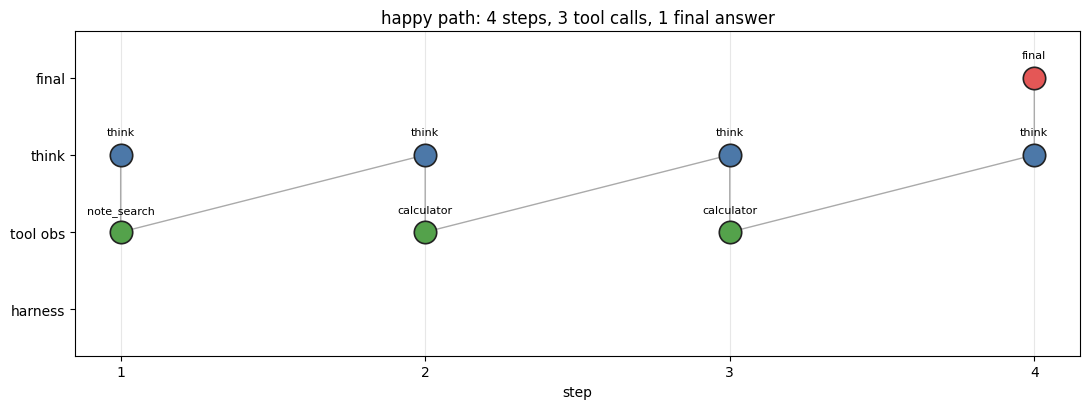

In [7]:
def plot_trace(trace, title="agent trace"):
    fig, ax = plt.subplots(figsize=(11, 4.2))
    lanes = {"think": 2, "obs": 1, "final": 3, "error": 0, "budget_exhausted": 0}
    lane_labels = {3: "final", 2: "think", 1: "tool obs", 0: "harness"}
    colors = {"think": "#4c78a8", "obs": "#54a24b", "final": "#e45756",
              "error": "#b279a2", "budget_exhausted": "#888"}

    for ev in trace:
        x = ev["step"]
        y = lanes.get(ev["kind"], 0)
        ax.scatter([x], [y], s=260, color=colors.get(ev["kind"], "#888"),
                   edgecolors="#222", linewidths=1.2, zorder=3)
        label = ev.get("tool") or ev["kind"]
        ax.annotate(label, (x, y), textcoords="offset points", xytext=(0, 14),
                    fontsize=8, ha="center")

    # connect them in order
    xs = [ev["step"] for ev in trace]
    ys = [lanes.get(ev["kind"], 0) for ev in trace]
    ax.plot(xs, ys, color="#aaa", lw=1, zorder=1)

    ax.set_yticks(list(lane_labels.keys()))
    ax.set_yticklabels([lane_labels[k] for k in lane_labels])
    ax.set_xlabel("step")
    ax.set_xticks(range(1, max(xs) + 1))
    ax.set_title(title)
    ax.set_ylim(-0.6, 3.6)
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_trace(result.trace, title="happy path: 4 steps, 3 tool calls, 1 final answer")

Read it left to right. Each step has a `think` (top), then either a tool observation (middle) or the final answer (top, red). The lines connect events in order. **Whenever you debug an agent, the first thing you should do is plot its trace.** It's astonishing how much that one chart explains.


## 9 · Break things on purpose

Now the part the title of this notebook is really about. We're going to inflict five distinct harness pathologies on this agent and watch them play out. The model is unchanged in all five demos — it's still our deterministic ReAct policy. So whatever goes wrong is, by construction, a harness bug.


### 9.1 · Failure 1: infinite loop (no budget cap)

A model that never emits `final_answer`, and a harness that never gives up, equals a process that runs until you `Ctrl-C` it. We simulate this with a model that always asks for one more search.


In [8]:
class NeverFinishesLLM:
    def __call__(self, prompt, history):
        return 'Thought: one more search to be sure.\nAction: note_search("Python")'

# WITHOUT a budget cap, this would hang forever. With max_steps=4, it bails.
agent_buggy = AgentHarness(llm=NeverFinishesLLM(), tools=TOOLS, max_steps=4, verbose=False)
r = agent_buggy.run("find oldest python note")
print(f"finished?    {r.done}")
print(f"steps used:  {r.step}")
print(f"final:       {r.final_answer}")
print(f"history len: {len(r.history)}  (would grow forever without max_steps)")

finished?    False
steps used:  4
final:       None
history len: 9  (would grow forever without max_steps)


The agent didn't *succeed* — it bailed at step 4 with no final answer — but it also didn't hang. The budget is the difference between a bug and a *outage*. Set it. Always. Even if you're sure the model will finish in two steps. *Especially* if you're sure.


### 9.2 · Failure 2: lost state from history truncation

This one is the most insidious. To save tokens, many production harnesses truncate the history when it gets long ("keep only the last N messages"). If a tool result was earlier than the window, it's gone — and the model doesn't know it's gone, it just confabulates.

We simulate by running our normal agent but with a harness that drops everything except the last 2 messages between iterations.


In [9]:
class TruncatingHarness(AgentHarness):
    def run(self, task):
        state = AgentState(task=task, max_steps=self.max_steps)
        state.history.append({"role": "system", "content": self.system_prompt(task)})
        while not state.done and state.step < state.max_steps:
            state.step += 1
            # *** THE BUG: we keep only the most recent assistant message. ***
            # Tool results from earlier steps are silently dropped.
            visible_history = [m for m in state.history[-1:] if m["role"] != "tool"]
            think = self.llm(self.system_prompt(task), visible_history)
            state.history.append({"role": "assistant", "content": think})
            state.trace.append({"step": state.step, "kind": "think", "text": think})
            tool, args = self.parse_action(think)
            if tool is None: break
            if tool == "final_answer":
                state.final_answer = args; state.done = True
                state.trace.append({"step": state.step, "kind": "final", "text": args})
                break
            obs = self.tools[tool](args) if tool in self.tools else f"ERROR: unknown tool {tool}"
            state.history.append({"role": "tool", "content": obs})
            state.trace.append({"step": state.step, "kind": "obs", "tool": tool, "text": obs})
        return state

bad = TruncatingHarness(llm=MockLLM(), tools=TOOLS, max_steps=8, verbose=False)
r2 = bad.run("...")
print(f"final answer: {r2.final_answer}")
print(f"steps:        {r2.step}")
print()
print("trace:")
for ev in r2.trace:
    print(f"  step {ev['step']:>2}  {ev['kind']:<6}  {(ev.get('tool') or '')+': ' if ev.get('tool') else ''}{ev['text'][:70]}")

final answer: None
steps:        8

trace:
  step  1  think   Thought: I need to find notes that mention "Python", then identify the
  step  1  obs     note_search: [{"id": "n2", "date": "2024-11-02"}, {"id": "n4", "date": "2025-03-14"
  step  2  think   Thought: I need to find notes that mention "Python", then identify the
  step  2  obs     note_search: [{"id": "n2", "date": "2024-11-02"}, {"id": "n4", "date": "2025-03-14"
  step  3  think   Thought: I need to find notes that mention "Python", then identify the
  step  3  obs     note_search: [{"id": "n2", "date": "2024-11-02"}, {"id": "n4", "date": "2025-03-14"
  step  4  think   Thought: I need to find notes that mention "Python", then identify the
  step  4  obs     note_search: [{"id": "n2", "date": "2024-11-02"}, {"id": "n4", "date": "2025-03-14"
  step  5  think   Thought: I need to find notes that mention "Python", then identify the
  step  5  obs     note_search: [{"id": "n2", "date": "2024-11-02"}, {"id": "n4", "date": "2025

Look at what happened. The model thinks it's at step 1 every time, because every time the harness asks it to think, all it sees is its own most recent message. So it just keeps re-issuing `note_search("Python")`. Same query, forever. It'll burn the budget and produce nothing.

In production, this looks **exactly** like a model that "got dumb." It isn't. It's a harness that lobotomized it.

The fix is to be deliberate about what gets pruned. Common patterns: keep the system prompt + a sliding window of recent turns, **plus** a summary of what was pruned, **plus** a list of tool results that are still relevant. Every framework that handles long agent runs (LangGraph, the Anthropic Agent SDK, etc.) has machinery for this.


### 9.3 · Failure 3: hallucinated tool calls

The model invents a tool that doesn't exist. A *naive* harness either crashes (KeyError on the dispatch dict) or — worse — silently does nothing and lets the model loop. Our harness handles this correctly: it returns an error observation. Let's prove it.


In [10]:
class HallucinatingLLM:
    def __init__(self): self.n = 0
    def __call__(self, prompt, history):
        self.n += 1
        if self.n == 1:
            return 'Thought: I will use the database tool.\nAction: sql_query("SELECT * FROM notes")'
        if self.n == 2:
            # The model sees the error and recovers.
            return 'Thought: oh, sql_query is not a real tool. Let me use note_search.\nAction: note_search("Python")'
        return 'Thought: done.\nAction: final_answer("recovered")'

agent_recover = AgentHarness(llm=HallucinatingLLM(), tools=TOOLS, max_steps=5, verbose=True)
agent_recover.run("find python notes");


[step 1] Thought: I will use the database tool.
Action: sql_query("SELECT * FROM notes")
  -> sql_query('SELECT * FROM notes') = ERROR: unknown tool 'sql_query'

[step 2] Thought: oh, sql_query is not a real tool. Let me use note_search.
Action: note_search("Python")
  -> note_search('Python') = [{"id": "n2", "date": "2024-11-02"}, {"id": "n4", "date": "2025-03-14"}, {"id": "n6", "date": "2025-10-04"}]

[step 3] Thought: done.
Action: final_answer("recovered")
  -> FINAL: recovered


Recovered in three steps. The model saw `ERROR: unknown tool 'sql_query'` and immediately corrected itself. This is what you want.

Now compare with a harness that crashes on unknown tools (which I have personally seen in production code more than once):

```python
# DON'T DO THIS
obs = self.tools[tool](args)   # KeyError if tool not in self.tools
```

A `KeyError` propagates up, kills the process, and your user sees a 500. The model never gets a chance to fix its own mistake. Tool errors should always be caught and returned as observations — the model is *much better* at recovering from errors than you'd guess, but only if you actually let it see them.


### 9.4 · Failure 4: bad final answer despite correct intermediate steps

The model called all the right tools, got all the right results, and then bungled the synthesis. This is a real and underrated failure mode. The fix is *not* a bigger model — the fix is to make the final-answer step more constrained.


In [11]:
class FumbleSynthLLM:
    def __init__(self): self.n = 0
    def __call__(self, prompt, history):
        self.n += 1
        if self.n == 1: return 'Action: note_search("Python")'
        if self.n == 2: return 'Action: calculator("529")'
        if self.n == 3: return 'Action: calculator("529 * 2")'
        # Bug: model copy-pastes the last calculator INPUT instead of its OUTPUT.
        return 'Action: final_answer("529 * 2")'

bad_synth = AgentHarness(llm=FumbleSynthLLM(), tools=TOOLS, max_steps=6, verbose=False)
r4 = bad_synth.run("...")
print("final answer:", r4.final_answer)
print("BUT the actual computed value was:")
for ev in r4.trace:
    if ev['kind'] == 'obs':
        print(" ", ev['text'])

final answer: 529 * 2
BUT the actual computed value was:
  [{"id": "n2", "date": "2024-11-02"}, {"id": "n4", "date": "2025-03-14"}, {"id": "n6", "date": "2025-10-04"}]
  529
  1058


The agent did the work — `1058` is sitting right there in the trace — and then handed back the literal string `"529 * 2"`. The intermediate steps were perfect; the final synthesis was garbage.

Mitigations, in increasing order of effectiveness:

1. **Add a synthesis prompt template** that explicitly references the last observation. ("Your last tool result was `{obs}`. Restate it as the answer.")
2. **Force structured output** for `final_answer` — e.g., a JSON schema with a numeric field. The model can't return prose if the schema demands an int.
3. **Add a verifier step**: after `final_answer`, run a cheap second pass that checks the answer against the trace.

Production agents often do all three. Notice that none of them are model upgrades.


### 9.5 · Failure 5: tool-call inflation

The agent gets the right answer, eventually, but takes 15 calls instead of 3. This costs you money and latency. The cause is almost always a vague task prompt or missing tool documentation.


In [12]:
class FumblingLLM:
    """Searches lots of unrelated terms before finally getting it right."""
    def __init__(self): self.queries = ["javascript", "rust", "backup", "sqlite", "zig", "homelab", "python"]; self.i = 0
    def __call__(self, prompt, history):
        # Did we already get python results?
        for m in history:
            if m["role"] == "tool" and "n2" in m["content"]:
                return 'Action: final_answer("n2")'
        if self.i < len(self.queries):
            q = self.queries[self.i]; self.i += 1
            return f'Action: note_search("{q}")'
        return 'Action: final_answer("gave up")'

inflated = AgentHarness(llm=FumblingLLM(), tools=TOOLS, max_steps=15, verbose=False)
r5 = inflated.run("find oldest python note")
print("final:", r5.final_answer, "in", r5.step, "steps")
n_searches = sum(1 for ev in r5.trace if ev.get('tool') == 'note_search')
print(f"note_search calls: {n_searches} (should be 1)")

final: n2 in 8 steps
note_search calls: 7 (should be 1)


Seven searches to find a Python note in a corpus of seven notes, when one targeted search would have done. The agent "succeeds" in the sense that it returns the right answer — but it's burning ~7× the cost it should.

This is the failure mode that's hardest to catch with unit tests, because the output is *correct*. You only notice it on your bill. The fixes are mostly about prompt engineering: include examples of efficient tool use in the system prompt, document each tool's capabilities clearly, and instrument every run with a tool-call counter. If the average call count for a task type drifts upward, something has regressed.


## 10 · The five failures, side by side

Here's a summary table you can screenshot and tape to your monitor.

| # | Failure | Root cause | Fix |
|---|---|---|---|
| 1 | Infinite loop | No budget cap in loop condition | `while step < max_steps` — non-negotiable |
| 2 | Lost state | Naive history truncation | Sliding window + summary + persistent tool results |
| 3 | Hallucinated tools | Harness crashes on unknown tools | Catch unknown tools, return error as observation |
| 4 | Bad synthesis | Final answer not constrained | Structured output schema, synthesis template, verifier |
| 5 | Tool-call inflation | Vague task / poor tool docs | Better system prompt, instrument call counts |

None of these are model failures. Every single one is something *you* control as the harness author.


## 11 · The SDK landscape (April 2026)

You don't have to write your own harness from scratch. You shouldn't, in production. You *should* understand how one works internally, which is what we just did. Here's the lay of the land as of April 2026.

- **Anthropic Claude Agent SDK** — Anthropic's own harness, originally shipped as the Claude Code SDK and renamed in late 2025. Python and TypeScript. Comes with a built-in tool loop, file/shell tools, and context-management primitives. As of April 2026 there's a public-beta **Claude Managed Agents** offering that runs the harness server-side with sandboxed containers — you upload a config and Anthropic runs the loop for you. ([docs](https://platform.claude.com/docs/en/agent-sdk/overview))

- **OpenAI Agents SDK** — released March 2025, replacing the experimental **Swarm** library. Three primitives: `Agent`, `Handoff`, `Guardrail`, plus first-class `Tracing`. Production-grade where Swarm was a sketch. ([docs](https://openai.github.io/openai-agents-python/))

- **Google Agent Development Kit (ADK)** — announced at Google Cloud Next April 2025, hit Python `v1.0` in May 2025, TypeScript joined December 2025. Code-first, model-agnostic, optimized for Gemini and Vertex AI. Strong on multi-agent orchestration. ([repo](https://github.com/google/adk-python))

- **LangGraph** — LangChain's "agents-as-stateful-graphs" approach. Nodes are functions, edges are control flow, state is a typed schema you own. Most explicit and debuggable of the bunch; the right call when failure is expensive. ([docs](https://langchain-ai.github.io/langgraph/))

- **Microsoft AutoGen v0.4** (a.k.a. **AG2**) — full async event-driven rewrite. Best-in-class for chat-style multi-agent setups (debate, code review, group brainstorms). Less great when control flow is naturally graph-shaped — that's prompt-engineering territory in AutoGen.

The differences matter less than you'd think for a single agent. They matter a lot when you go to multi-agent — which is Module 32.

A pragmatic rule of thumb:

| You want... | Reach for... |
|---|---|
| Claude-native, want managed infra | Claude Agent SDK / Managed Agents |
| Already deep in the OpenAI ecosystem | OpenAI Agents SDK |
| Gemini, multi-agent, want Google support | Google ADK |
| Explicit graph, full control, critical infra | LangGraph |
| Conversational multi-agent, prototyping | AutoGen v0.4 |
| Educational, want to *understand* | Write your own. Like we just did. |


## 12 · The thesis, restated

If you only remember one thing from this module, make it this:

> **Most agent failures are harness failures.** Your agent isn't dumb. Your loop is broken, your state is leaking, your budget is uncapped, your tool errors are crashing the process instead of becoming observations, your synthesis prompt is vague, and your truncation policy is silently amputating the model's memory.

Second thing to remember: build a trace from day one. The five failures we just demoed all become *obvious* the moment you can see the trace. Without one, they look like a sad mystery you can only solve by re-running the agent and praying.

Third thing: your "100-line harness" can take you surprisingly far. The big SDKs add real value at the multi-agent / production / observability layer, but the core loop is genuinely 100 lines. If you don't understand those 100 lines, you don't understand your agent. If you do, you can debug anyone's framework.


## 13 · Bridge to Module 32

One agent is hard. We just spent a whole module getting one to work, and we still found five ways to break it.

Now imagine *several* agents, talking to each other, with their own tools and their own state, possibly in parallel, possibly handing off context. That's Module 32, and it's where things get genuinely interesting — including the **KIMI K2.5 agent swarm** that landed in January 2026 and turned heads on BrowseComp by spawning up to 100 parallel sub-agents from a single model call.

Bring this module's mental model with you. Multi-agent systems aren't a new thing — they're the *same* loop, just with more state to lose, more tools to hallucinate, more budgets to blow, and more places for the harness to be the actual problem.


## Checkpoint quiz

Test yourself before moving on to Module 32.

1. Why is the budget check in the `while` loop **condition**, not in an `if` inside the loop? What goes wrong if you put it in an `if`?
2. The harness returns errors from tools as **observation strings** rather than raising Python exceptions. Why? What does this enable the model to do?
3. In the "lost state" demo, the model kept issuing `note_search("Python")` over and over. From the model's perspective, what was different about each iteration — and why did the truncation policy hide that difference?
4. Your agent gets the right answer in 12 tool calls when 3 would do. The unit test passes. Where would you instrument the harness to catch the regression on the next deploy?
5. You see the model emit `Action: query_db("SELECT * FROM notes")` for a tool you never registered. Two failure-mode options: (a) the harness crashes; (b) the harness returns `ERROR: unknown tool 'query_db'` and lets the model retry. Which is correct, and what does the *wrong* option look like to a downstream user?
6. The Anthropic Agent SDK, OpenAI Agents SDK, Google ADK, LangGraph, and AutoGen v0.4 all wrap roughly the same core loop. What's the strongest reason to use one over a hand-rolled 100-line harness in a production deployment?
